# Day 2 · 03 SIMPLE — Save the model for the web app (ONNX) 📤

**The problem:** our model lives inside PyTorch. PyTorch is **big** (hundreds of MB to install) and the program
that uses the model also needs our Python code for the model. Tomorrow (Day 3) we build a **small web app**.
We don't want to carry all of PyTorch into it.

**The solution: ONNX** — think of it as the **PDF of models**:

| Documents | Models |
|---|---|
| you write in Word (big program) | you train in **PyTorch** (big program) |
| you save as **PDF** — one file, anyone can open it | you export to **ONNX** — one `.onnx` file |
| a small PDF reader opens it | a small **ONNX Runtime** (~15 MB) runs it — no PyTorch needed |

```
 PyTorch model (.pth)  ──export──▶  model.onnx  ──▶  ONNX Runtime  ──▶  "ship, 85 %"
      (training)                     (one file)       (small, fast)
```

What we do: **1** export → **2** check it gives the same answers → **3** measure speed →
**4** make an int8 version → **5** compare → **6** use it like the web app will.

⏱️ Runs in about 1 minute. Files are saved in `outputs/simple/` (the real app uses `../models/`, made by the
full notebook `03_onnx_export_and_benchmark.ipynb` in exactly the same way).

## Step 0 — Setup

Loads the trained PyTorch model and 1 000 test pictures. Run it and move on.

In [1]:
import time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import onnxruntime as ort
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2

warnings.filterwarnings("ignore")
DATA_DIR, MODELS_DIR = Path("..") / "data", Path("..") / "models"
OUT = Path("outputs") / "simple"; OUT.mkdir(parents=True, exist_ok=True)
LABELS = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
prep = transforms.Compose([transforms.Resize((96, 96)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

model = mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(1280, 10)
model.load_state_dict(torch.load(MODELS_DIR / "mobilenetv2_cifar10_fp32.pth", map_location="cpu", weights_only=True))
model.eval()

def some_as_numpy(train, n, seed):                 # n pictures as one NumPy array (what ONNX Runtime eats)
    ds = datasets.CIFAR10(DATA_DIR, train=train, download=True, transform=prep)
    idx = torch.randperm(len(ds), generator=torch.Generator().manual_seed(seed))[:n].tolist()
    return (np.stack([ds[i][0].numpy() for i in idx]).astype(np.float32), np.array([ds[i][1] for i in idx]))

X_test, y_test = some_as_numpy(train=False, n=1000, seed=42)
print("ready ✔  | test pictures:", X_test.shape, "→ (pictures, colours, height, width)")

ready ✔  | test pictures: (1000, 3, 96, 96) → (pictures, colours, height, width)


## Step 1 — Export to ONNX

`torch.onnx.export` runs the model **once** on a fake picture and writes down every calculation it does
into a file. The 4 settings, in plain words:

| Setting | Meaning |
|---|---|
| `input_names=["input"]` | the name of the "door" where pictures go in |
| `output_names=["logits"]` | the name of the "door" where the 10 scores come out |
| `dynamic_axes=...` | "the number of pictures per call can change" (1 today, 32 tomorrow) |
| `opset_version=17` | which version of the ONNX "language" to write |

In [2]:
fake_picture = torch.randn(1, 3, 96, 96)             # any picture of the right shape
torch.onnx.export(model, fake_picture, OUT / "model_fp32.onnx",
                  input_names=["input"], output_names=["logits"],
                  dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
                  opset_version=17, dynamo=False)

print(f"saved: {OUT / 'model_fp32.onnx'}  ({(OUT / 'model_fp32.onnx').stat().st_size / 1e6:.1f} MB)")

saved: outputs\simple\model_fp32.onnx  (8.9 MB)


👀 One file, ~9 MB — the same size as the PyTorch weights. Nothing was lost, only the *format* changed.

---

## Step 2 — Does it give the same answers?

A saved file is useless if it computes something different. We ask both — PyTorch and ONNX Runtime —
about the same 8 pictures.

In [3]:
onnx_model = ort.InferenceSession(str(OUT / "model_fp32.onnx"))          # open the file with ONNX Runtime

pictures = X_test[:8]
with torch.no_grad():
    scores_pytorch = model(torch.from_numpy(pictures)).numpy()
scores_onnx = onnx_model.run(["logits"], {"input": pictures})[0]     # "put pictures in the door called input"

display(pd.DataFrame({"true answer": [LABELS[i] for i in y_test[:8]],
                      "PyTorch says": [LABELS[i] for i in scores_pytorch.argmax(1)],
                      "ONNX says": [LABELS[i] for i in scores_onnx.argmax(1)]}))
print(f"biggest difference in the scores: {np.abs(scores_pytorch - scores_onnx).max():.7f}")

,true answer,PyTorch says,ONNX says
0,ship,ship,ship
1,automobile,automobile,automobile
2,ship,ship,ship
3,bird,bird,bird
4,deer,deer,deer
5,deer,deer,deer
6,truck,truck,truck
7,ship,ship,ship


biggest difference in the scores: 0.0000041


👀 **Same answers.** The scores differ only in the 6th–7th decimal place (tiny rounding differences
between two programs) — nothing a user could ever see.

---

## Step 3 — Is it faster?

Time 1 picture, 200 times, in both.

In [4]:
def time_ms(run, n=200):
    for _ in range(20): run()                          # warm up
    t = []
    for _ in range(n):
        t0 = time.perf_counter(); run(); t.append((time.perf_counter() - t0) * 1000)
    return float(np.median(t))

one = X_test[:1]
torch.set_num_threads(4)
with torch.no_grad():
    t_pytorch = time_ms(lambda: model(torch.from_numpy(one)))
t_onnx = time_ms(lambda: onnx_model.run(None, {"input": one}))
print(f"PyTorch      : {t_pytorch:.2f} ms per picture")
print(f"ONNX Runtime : {t_onnx:.2f} ms per picture   → {t_pytorch / t_onnx:.1f}× faster")

PyTorch      : 6.13 ms per picture
ONNX Runtime : 0.75 ms per picture   → 8.2× faster


👀 **Much faster — with the very same weights.** ONNX Runtime looks at the whole list of calculations
first and merges steps together (like planning all your errands before leaving the house), then runs in
fast C++ code. PyTorch runs one step at a time.

---

## Step 4 — Make an int8 version (quantization, like Notebook 02)

Same idea as in Notebook 02: round every number to 1 byte. ONNX Runtime does it in **one function call**.
It only needs to **see ~200 training pictures** first (calibration), given to it by a tiny "reader":
each time it asks, we hand over the next 32 pictures, and `None` when we are out of pictures.

In [5]:
from onnxruntime.quantization import CalibrationDataReader, QuantFormat, QuantType, quantize_static
from onnxruntime.quantization.shape_inference import quant_pre_process

X_calib, _ = some_as_numpy(train=True, n=200, seed=43)          # TRAINING pictures, never test pictures

class PictureReader(CalibrationDataReader):
    def __init__(self, data):
        self.batches = iter([{"input": data[i:i + 32]} for i in range(0, len(data), 32)])
    def get_next(self):
        return next(self.batches, None)                          # next 32 pictures, or None when finished

quant_pre_process(OUT / "model_fp32.onnx", OUT / "model_ready.onnx")     # tidy the file first
quantize_static(OUT / "model_ready.onnx", OUT / "model_int8.onnx", PictureReader(X_calib),
                quant_format=QuantFormat.QDQ, per_channel=True,
                activation_type=QuantType.QUInt8, weight_type=QuantType.QInt8)
print(f"saved: {OUT / 'model_int8.onnx'}  ({(OUT / 'model_int8.onnx').stat().st_size / 1e6:.1f} MB)")

saved: outputs\simple\model_int8.onnx  (2.6 MB)


The settings are the standard recipe for CPUs — you don't need to change them.
(`per_channel=True` = every filter gets its own "step size", which keeps the rounding error small.)

---

## Step 5 — Compare float32 and int8

In [6]:
rows, answers = [], {}
for name in ["model_fp32.onnx", "model_int8.onnx"]:
    s = ort.InferenceSession(str(OUT / name))
    answers[name] = np.concatenate([s.run(None, {"input": X_test[i:i + 100]})[0].argmax(1)
                                    for i in range(0, len(X_test), 100)])
    rows.append({"file": name,
                 "📦 size_MB": round((OUT / name).stat().st_size / 1e6, 2),
                 "⚡ ms per picture": round(time_ms(lambda: s.run(None, {"input": one})), 2),
                 "🎯 accuracy_%": round(100 * (answers[name] == y_test).mean(), 1)})
display(pd.DataFrame(rows).set_index("file"))
same = (answers["model_fp32.onnx"] == answers["model_int8.onnx"]).mean()
print(f"the two files give the same answer for {100 * same:.1f} % of the pictures")

,📦 size_MB,⚡ ms per picture,🎯 accuracy_%
file,,,
model_fp32.onnx,8.92,0.75,88.8
model_int8.onnx,2.61,0.71,88.6


the two files give the same answer for 96.0 % of the pictures


👀 **What to notice:** the int8 file is **~3.4× smaller**, about as fast or faster, and the accuracy moves by
less than 1 point. It changes the answer for only a few pictures out of 100 — usually pictures the model
was unsure about anyway.

➡️ **This int8 file is exactly what our web app serves on Day 3.**

---

## Step 6 — Use it like the web app will (no PyTorch!)

The web app only has `numpy`, `Pillow` and `onnxruntime`. So it prepares the picture with plain NumPy —
**exactly** the same steps as in training (resize to 96×96 → 0..1 → subtract mean ÷ std → reorder).

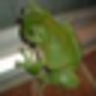

true answer: frog   |   the int8 ONNX model says: frog (93 % sure)


In [7]:
from PIL import Image

def picture_to_numbers(img):                                     # the same steps as training, in NumPy
    img = img.convert("RGB").resize((96, 96), Image.BILINEAR)
    x = np.asarray(img, dtype=np.float32) / 255.0
    x = (x - np.array(MEAN, np.float32)) / np.array(STD, np.float32)
    return x.transpose(2, 0, 1)[None].astype(np.float32)          # (1 picture, colour, height, width)

img, label = datasets.CIFAR10(DATA_DIR, train=False, download=True)[7]
app_model = ort.InferenceSession(str(OUT / "model_int8.onnx"))
scores = app_model.run(None, {"input": picture_to_numbers(img)})[0][0]
probs = np.exp(scores - scores.max()); probs /= probs.sum()      # scores → percentages (softmax)

display(img.resize((96, 96)))
print(f"true answer: {LABELS[label]}   |   the int8 ONNX model says: {LABELS[probs.argmax()]} ({100 * probs.max():.0f} % sure)")

👀 That little function + 3 lines is the heart of tomorrow's `/predict` endpoint
(`Day3_Serving_Flask_Streamlit/simple/step2_predict_api.py`).

## 🎓 What to remember

1. **ONNX** = one portable file for a model (the "PDF of models"); **ONNX Runtime** runs it without PyTorch.
2. **Always check** the exported file gives the same answers as PyTorch.
3. ONNX Runtime is **several times faster** for the same model — for free.
4. `quantize_static` makes the **int8** version (~3.4× smaller, almost the same accuracy) → served on Day 3.
5. The web app must prepare pictures **exactly like training** — otherwise answers go wrong silently.

**Want more?** The full notebook `03_onnx_export_and_benchmark.ipynb` shows what is inside the ONNX graph,
the optimisation levels, dynamic int8, and writes the `model_card.json` that the Day 3 API reads.